# Foundations of AI Assignment

**Name:** Michael Ochieng  
**Registration Number:** CIT-227-033/2024  
**Unit:** Foundations of AI  
**Course:** Software Engineering

## TASK 2
**Constraint Satisfaction Program**
- Using the Map of Australia, write a colouring constraint program to
colour the five regions using three colours. No two adjacent regions to
have the same colour. Colours: Blue, Red, Green.

**Below Shows the image I will be using**


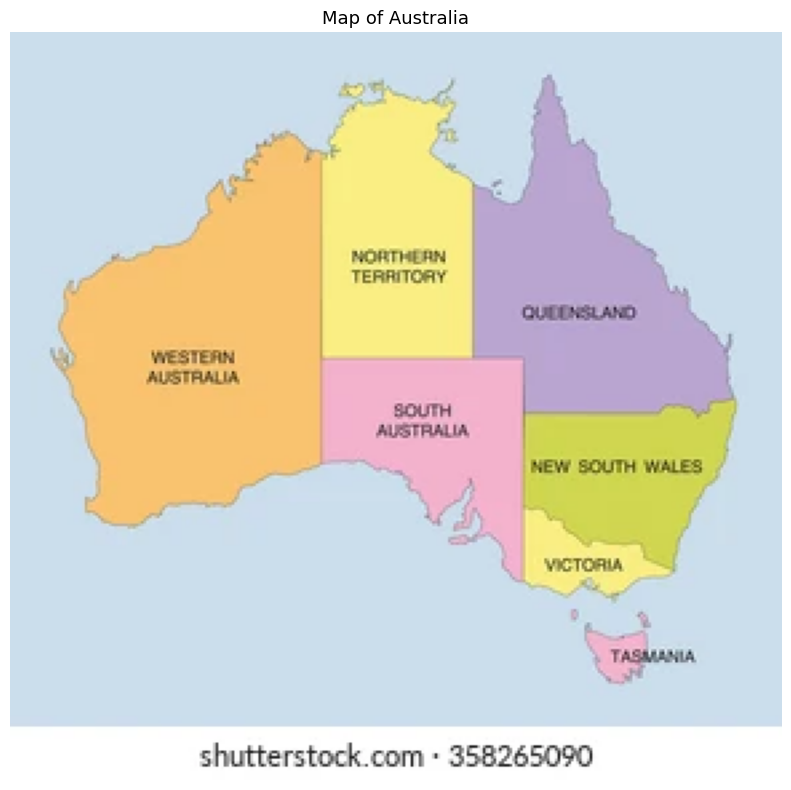

In [9]:
# pip install python-constraint pillow matplotlib

from constraint import Problem
from PIL import Image
import matplotlib.pyplot as plt

# Load and display the image
img = Image.open("australiamap.png")

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title("Map of Australia", fontsize=13)
plt.tight_layout()
plt.show()

CSP Colouring Solution:
------------------------------
  SA    → Green
  NSW   → Red
  QLD   → Blue
  NT    → Red
  VIC   → Blue
  WA    → Blue
  TAS   → Green


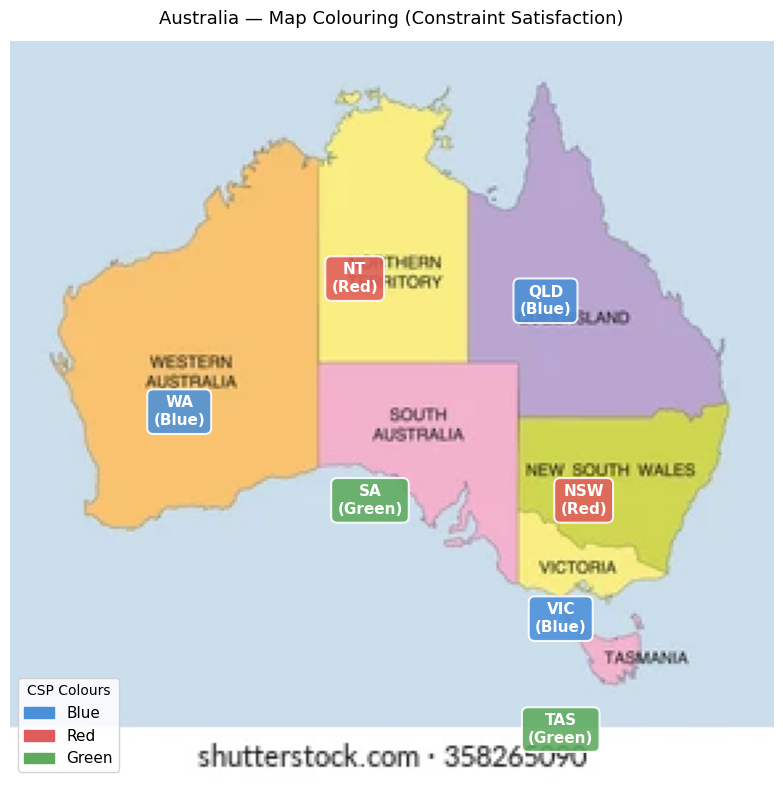


Saved as australia_coloured.png


In [10]:
# pip install python-constraint pillow matplotlib

from constraint import Problem
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─── (a) Load the Australia map image ─────────────────────────────────────────
img = Image.open("australiamap.png")

# ─── (b) Constraint Satisfaction Problem ──────────────────────────────────────
problem = Problem()

regions = ['WA', 'NT', 'SA', 'QLD', 'NSW', 'VIC', 'TAS']
colors  = ['Blue', 'Red', 'Green']

for region in regions:
    problem.addVariable(region, colors)

# Real adjacencies from the map
adjacencies = [
    ('WA',  'NT'),
    ('WA',  'SA'),
    ('NT',  'SA'),
    ('NT',  'QLD'),
    ('SA',  'QLD'),
    ('SA',  'NSW'),
    ('SA',  'VIC'),
    ('QLD', 'NSW'),
    ('NSW', 'VIC'),
    # TAS is an island — no land adjacencies
]

for r1, r2 in adjacencies:
    problem.addConstraint(lambda a, b: a != b, (r1, r2))

solution = problem.getSolution()

print("CSP Colouring Solution:")
print("-" * 30)
for region, color in solution.items():
    print(f"  {region:5s} → {color}")

# ─── (c) Display the map image with colour labels overlaid ────────────────────
color_map = {
    'Blue':  '#4A90D9',
    'Red':   '#E05C5C',
    'Green': '#5DAA5D',
}

# Approximate label positions on the image (x, y as fractions of image size)
label_positions = {
    'WA':  (0.22, 0.50),
    'NT':  (0.45, 0.32),
    'SA':  (0.47, 0.62),
    'QLD': (0.70, 0.35),
    'NSW': (0.75, 0.62),
    'VIC': (0.72, 0.78),
    'TAS': (0.72, 0.93),
}

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.axis('off')

for region, (fx, fy) in label_positions.items():
    w, h = img.size
    x, y = fx * w, fy * h
    c = solution[region]
    ax.annotate(
        f"{region}\n({c})",
        xy=(x, y),
        fontsize=11,
        fontweight='bold',
        color='white',
        ha='center', va='center',
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor=color_map[c],
            edgecolor='white',
            linewidth=1.5,
            alpha=0.88
        )
    )

# Legend
legend_patches = [
    mpatches.Patch(color=color_map[c], label=c)
    for c in ['Blue', 'Red', 'Green']
]
ax.legend(handles=legend_patches, loc='lower left',
          fontsize=11, framealpha=0.85, title='CSP Colours')

ax.set_title("Australia — Map Colouring (Constraint Satisfaction)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("australia_coloured.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved as australia_coloured.png")

- Using the same concept, colour Nairobi sub-counties using the least
possible number of colours. Nairobi has 17 sub-counties. You can have a
simulative or real map of Nairobi.



In [13]:
from constraint import Problem

problem = Problem()

subcounties = [
    'Westlands', 'Dagoretti North', 'Dagoretti South', 'Langata',
    'Kibra', 'Roysambu', 'Kasarani', 'Ruaraka', 'Embakasi South',
    'Embakasi North', 'Embakasi Central', 'Embakasi East', 'Embakasi West',
    'Makadara', 'Kamukunji', 'Starehe', 'Mathare'
]

adjacencies = [
    ('Westlands', 'Dagoretti North'), ('Westlands', 'Roysambu'),
    ('Westlands', 'Starehe'), ('Westlands', 'Kamukunji'),
    ('Dagoretti North', 'Dagoretti South'), ('Dagoretti North', 'Kibra'),
    ('Dagoretti South', 'Kibra'), ('Dagoretti South', 'Langata'),
    ('Langata', 'Kibra'), ('Langata', 'Embakasi West'),
    ('Kibra', 'Makadara'), ('Kibra', 'Kamukunji'),
    ('Roysambu', 'Kasarani'), ('Roysambu', 'Starehe'),
    ('Kasarani', 'Ruaraka'), ('Kasarani', 'Embakasi North'),
    ('Ruaraka', 'Embakasi North'), ('Ruaraka', 'Mathare'),
    ('Mathare', 'Starehe'), ('Mathare', 'Kamukunji'),
    ('Starehe', 'Kamukunji'), ('Kamukunji', 'Makadara'),
    ('Makadara', 'Embakasi South'), ('Makadara', 'Embakasi Central'),
    ('Embakasi West', 'Embakasi Central'), ('Embakasi West', 'Embakasi South'),
    ('Embakasi Central', 'Embakasi East'), ('Embakasi Central', 'Embakasi South'),
    ('Embakasi Central', 'Embakasi North'), ('Embakasi East', 'Embakasi North'),
]

# Try increasing number of colours until a solution is found
for k in range(2, 6):
    p = Problem()
    colors = list(range(k))
    for sc in subcounties:
        p.addVariable(sc, colors)
    for r1, r2 in adjacencies:
        p.addConstraint(lambda a, b: a != b, (r1, r2))
    solution = p.getSolution()
    if solution:
        color_names = ['Red', 'Green', 'Blue', 'Yellow']
        print(f"Minimum colours needed: {k}\n")
        for region, c in solution.items():
            print(f"  {region:25s} -> {color_names[c]}")
        break

Minimum colours needed: 3

  Embakasi Central          -> Blue
  Kamukunji                 -> Blue
  Kibra                     -> Green
  Makadara                  -> Red
  Embakasi North            -> Green
  Starehe                   -> Green
  Westlands                 -> Red
  Dagoretti North           -> Blue
  Dagoretti South           -> Red
  Embakasi South            -> Green
  Embakasi West             -> Red
  Langata                   -> Blue
  Mathare                   -> Red
  Roysambu                  -> Blue
  Kasarani                  -> Red
  Ruaraka                   -> Blue
  Embakasi East             -> Red
